In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import pandas as pd

images_base_path = '/content/drive/MyDrive/ROCO/data/train/radiology/images'
captions_file = '/content/drive/MyDrive/ROCO/data/train/radiology/captions_filtered.txt'

def load_data(captions_file, images_base_path):
    image_files = {os.path.splitext(img)[0] for img in os.listdir(images_base_path)}
    data = []

    with open(captions_file, 'r') as file:
        for line in file:
            caption_id, caption_text = line.strip().split("\t", 1)
            if caption_id in image_files:
                data.append({"caption": caption_text, "image_id": caption_id})
    old_df = pd.DataFrame(data)
    return old_df

old_df = load_data(captions_file, images_base_path)

CROSS_CHECKING PART


In [16]:
df= old_df.head(10)
df.head(5)

,caption,image_id
0,Two sequential thrombi in the distal segment ...,ROCO_00011
1,Coronary angiogram demonstrating occluded OM1...,ROCO_00017
2,Right-sided metatarsal in dorsoplantar projec...,ROCO_00021
3,Orthopantomograph,ROCO_00023
4,Abdominal CT scan showing pancreatic pseudocyst,ROCO_00030


IMPORTING ALL LIBRARIES


In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Add
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

LOADING THE MODEL

In [5]:
base_model = InceptionV3(weights="imagenet")
image_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


EXTRACTING FEATURES FROM IMAGES

In [6]:
def extract_features(image_path, model):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(299, 299))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    features = model.predict(img, verbose=0)
    return features

PREPROCESSING THE CAPTIONS

In [7]:
def preprocess_captions(captions):

    tokenizer = Tokenizer(filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')

    tokenizer.fit_on_texts([f"<start> {caption} <end>" for caption in captions])

    captions = [f"<start> {caption} <end>" for caption in captions]
    sequences = tokenizer.texts_to_sequences(captions)
    max_length = max(len(seq) for seq in sequences)
    vocab_size = len(tokenizer.word_index) + 1
    return tokenizer, sequences, max_length, vocab_size

MODEL CREATION

In [8]:
def create_model(vocab_size, max_length):
    image_input = Input(shape=(2048,), name="image_input")
    image_dense = Dense(256, activation="relu", name="image_dense")(image_input)

    text_input = Input(shape=(max_length,))
    text_embedding = Embedding(vocab_size, 256, mask_zero=True)(text_input)
    text_lstm = LSTM(256)(text_embedding)

    decoder = Add()([image_dense, text_lstm])
    decoder_dense = Dense(256, activation="relu")(decoder)
    output = Dense(vocab_size, activation="softmax")(decoder_dense)

    model = Model(inputs=[image_input, text_input], outputs=output)
    return model

FUNCTION FOR DATA GENERATION

In [9]:
def data_generator(df, image_features, tokenizer, max_length, vocab_size, batch_size):
    while True:
        batch_features, batch_inputs, batch_outputs = [], [], []
        for _, row in df.iterrows():
            image_id = row['image_id']
            caption = row['caption']

            image_feature = image_features[image_id][0]

            seq = tokenizer.texts_to_sequences([caption])[0]

            for i in range(1, len(seq)):
                input_seq = seq[:i]
                output_word = seq[i]

                input_seq = pad_sequences([input_seq], maxlen=max_length, padding='post')[0]

                output_word = tf.keras.utils.to_categorical([output_word], num_classes=vocab_size)[0]

                batch_features.append(image_feature)
                batch_inputs.append(input_seq)
                batch_outputs.append(output_word)

                if len(batch_features) == batch_size:
                    yield (
                        (np.array(batch_features, dtype=np.float32),
                         np.array(batch_inputs, dtype=np.float32)),
                        np.array(batch_outputs, dtype=np.float32)
                    )
                    batch_features, batch_inputs, batch_outputs = [], [], []

LOADING THE FEATURES

In [17]:
all_captions = df['caption'].tolist()

tokenizer, sequences, max_length, vocab_size = preprocess_captions(all_captions)

unique_image_ids = df['image_id'].unique()
image_features = {image_id: extract_features(f"/content/drive/MyDrive/ROCO/data/train/radiology/images/{image_id}.jpg", image_model) for image_id in unique_image_ids}

MODEL COMPILATION

In [18]:
model = create_model(vocab_size, max_length)
model.compile(optimizer='adam',
loss='categorical_crossentropy',
              metrics=['accuracy'])

batch_size = 8
steps_per_epoch = sum(len(seq) - 1 for seq in sequences) // batch_size

In [19]:
dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(df, image_features, tokenizer, max_length, vocab_size, batch_size),
    output_signature=(
        (
            tf.TensorSpec(shape=(None, 2048), dtype=tf.float32),
            tf.TensorSpec(shape=(None, max_length), dtype=tf.float32)
        ),
        tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
    )
)

RUNNING THE MODEL FOR 50 EPOCHS

In [20]:
model.fit(dataset, steps_per_epoch=steps_per_epoch, epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.0192 - loss: 4.8057
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.0498 - loss: 4.3616
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.0737 - loss: 3.9760
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.1183 - loss: 3.5468
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.1962 - loss: 2.9624
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.1274 - loss: 2.7467
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.1535 - loss: 2.5120
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.1577 - loss: 2.9223
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.1521 - loss: 2.7894
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.2519 - loss: 2.1727
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.2469 - loss: 2.0591
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accur

In [ ]:
model.save("image_caption_model1.keras")


FUNCTION FOR EVALUATION OF BLEU SCORE

In [21]:
def evaluate_bleu(df, model, tokenizer, max_length):
    bleu1_scores = []
    bleu2_scores = []
    smooth = SmoothingFunction()

    for _, row in df.iterrows():
        image_id = row['image_id']
        actual_caption = row['caption']
        image_path = f"/content/drive/MyDrive/ROCO/data/train/radiology/images/{image_id}.jpg"

        generated_caption = generate_caption(image_path, model, tokenizer, max_length)

        reference = [actual_caption.split()]
        hypothesis = generated_caption.split()

        bleu1 = sentence_bleu(reference, hypothesis, weights=(1, 0, 0, 0), smoothing_function=smooth.method1)
        bleu2 = sentence_bleu(reference, hypothesis, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth.method1)

        bleu1_scores.append(bleu1)
        bleu2_scores.append(bleu2)

    avg_bleu1 = sum(bleu1_scores) / len(bleu1_scores)
    avg_bleu2 = sum(bleu2_scores) / len(bleu2_scores)
    return avg_bleu1, avg_bleu2


FUNC FOR FINAL CAPTION GENERATION

In [22]:
def generate_caption(image_path, model, tokenizer, max_length):
    feature = extract_features(image_path, image_model)[0]

    input_seq = [tokenizer.word_index['<start>']]
    for _ in range(max_length):
        padded_seq = pad_sequences([input_seq], maxlen=max_length, padding="post")
        prediction = model.predict([np.expand_dims(feature, axis=0), padded_seq], verbose=0)
        predicted_id = np.argmax(prediction)

        predicted_word = tokenizer.index_word.get(predicted_id, None)
        if predicted_word == '<end>':
            break
        input_seq.append(predicted_id)
    return " ".join([tokenizer.index_word.get(i, "") for i in input_seq[1:]])


FINAL OUTPUT ANALYSIS

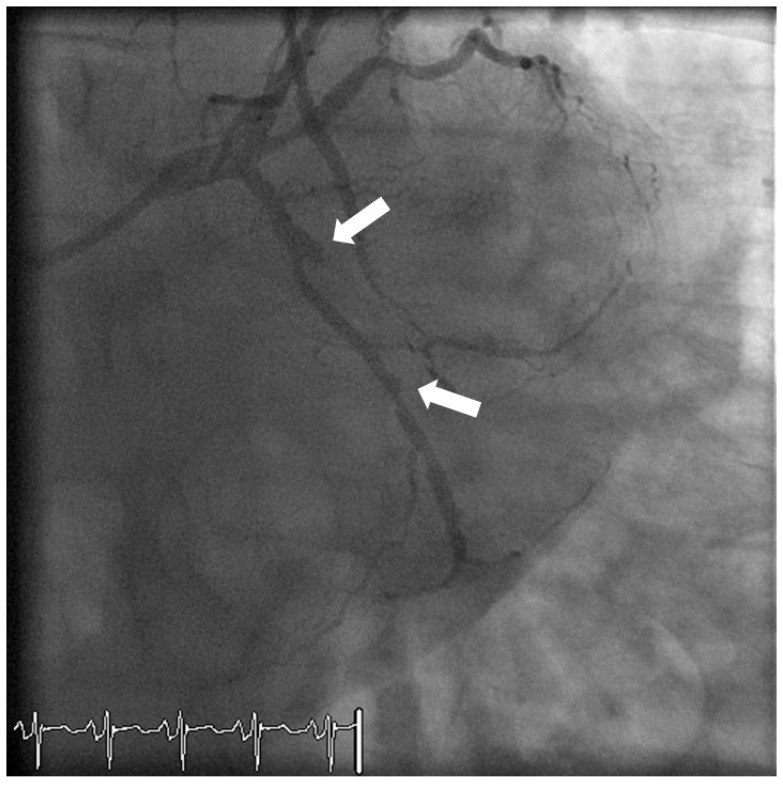

Actual Caption:  Coronary angiogram demonstrating occluded OM1 and OM2 arteries.
Generated Caption: angiogram angiogram demonstrating occluded om1 and om2 arteries arteries angiogram angiogram occluded occluded om2 demonstrating occluded om1 om2 arteries arteries arteries angiogram demonstrating occluded om1


Average BLEU-1 Score: 0.3160
Average BLEU-2 Score: 0.2815


In [23]:
from IPython.display import Image, display


image_id = "ROCO_00017"
image_path = f"/content/drive/MyDrive/ROCO/data/train/radiology/images/{image_id}.jpg"

actual_caption = df[df['image_id'] == image_id]['caption'].values[0]

caption = generate_caption(image_path, model, tokenizer, max_length)

display(Image(filename=image_path))
print(f"Actual Caption: {actual_caption}")
print(f"Generated Caption: {caption}")
print("\n")
avg_bleu1, avg_bleu2 = evaluate_bleu(df, model, tokenizer, max_length)
print(f"Average BLEU-1 Score: {avg_bleu1:.4f}")
print(f"Average BLEU-2 Score: {avg_bleu2:.4f}")